# 1. State the question (Regression Problem)
# Name: Cameron Mangione
How does Year, Salary and Remote_Ratio impact our variable of Salary in USD?

# 2. Identify the response and relevant predictors
Salary in USD is the response variable, while the Salary, Year, and Remote_ratio are the predictor variables.

# 3. Related data preparation
We first start with filtering only for the numeric variable types, importing our libraries and our dataset, and then filtering our dataset for numeric values only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import train_test_split
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from ISLP.bart import BART
from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

In [2]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_merged_final.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [3]:
df = df[['work_year','salary','salary_in_usd','remote_ratio']]
df.head()

,work_year,salary,salary_in_usd,remote_ratio
0,2020,15000,15000,0
1,2020,95000,95000,0
2,2020,1000000,13493,100
3,2020,20000,22809,100
4,2020,43200,49268,0


In [4]:
df['work_year'].value_counts()

work_year
2022    1196
2023    1156
2021     238
2020      78
Name: count, dtype: int64

# 4. Apply the bagging, random forest, and boosting approach learned in class

In [5]:
# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(df.drop('salary_in_usd',axis = 1)
                                                 ,df['salary_in_usd']
                                                 ,train_size = 1512, test_size = 1156
                                                 ,random_state = 2)

In [6]:
# fit Random Forests model (Bagging)
bagging = RandomForestRegressor(max_features=X_train.shape[1],random_state = 2)
bagging.fit(X_train,y_train)

print("Number of trees:", bagging.n_estimators)
print("Number of features tried at each split:",bagging.max_features)
print("Training score: {:.2f}%".format(bagging.score(X_train,y_train)*100))

Number of trees: 100
Number of features tried at each split: 3
Training score: 96.39%


In [7]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bagging = pd.DataFrame({'Feature': X_train.columns, 'Importance': bagging.feature_importances_})
importances_df_bagging = importances_df_bagging.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bagging)

        Feature  Importance
0        salary    0.942095
1     work_year    0.034110
2  remote_ratio    0.023795


How well does this bagged model perform on the test set?

Text(0, 0.5, 'Actual values')

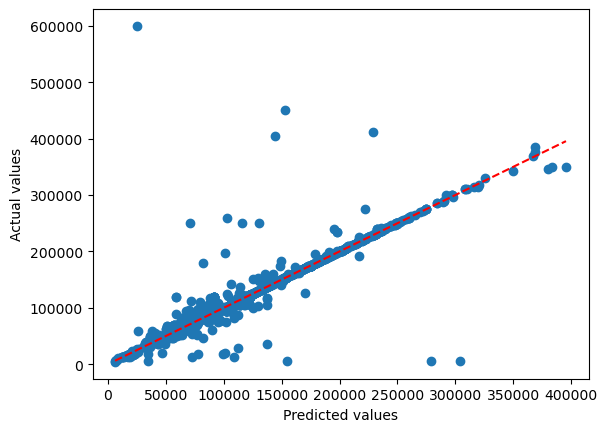

In [8]:
# Predict values
y_pred_bag = bagging.predict(X_test)

# plot predicted vs actual values
plt.scatter(y_pred_bag, y_test)
plt.plot([min(y_pred_bag), max(y_pred_bag)], [min(y_pred_bag), max(y_pred_bag)], 'r--')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')

In [9]:
# find the MSE
MSE_bag = mean_squared_error(y_test, y_pred_bag)
RMSE_bag = np.sqrt(MSE_bag)
print("Mean Squared Error: {:.2f}".format(MSE_bag))
print("Root Mean Squared Error: {:.2f}".format(RMSE_bag))

Mean Squared Error: 810551884.68
Root Mean Squared Error: 28470.19


In [10]:
# fit Random Forests model (Fewer Estimators)
bagging2 = RandomForestRegressor(max_features=X_train.shape[1]
                                       ,random_state = 2
                                       ,n_estimators=25)

bagging2.fit(X_train,y_train)

# Predict values
y_pred_bag = bagging2.predict(X_test)

# find the MSE
MSE_bag2 = mean_squared_error(y_test, y_pred_bag)
RMSE_bag2 = np.sqrt(MSE_bag2)
print("Mean Squared Error: {:.2f}".format(MSE_bag2))
print("Root Mean Squared Error: {:.2f}".format(RMSE_bag2))

Mean Squared Error: 817459319.41
Root Mean Squared Error: 28591.25


In [11]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bag = pd.DataFrame({'Feature': X_train.columns, 'Importance': bagging2.feature_importances_})
importances_df_bag = importances_df_bag.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bag)

        Feature  Importance
0        salary    0.943418
1     work_year    0.033329
2  remote_ratio    0.023253


In [12]:
# fit Random Forests model
df_rf = RandomForestRegressor(max_features=2
                                       ,random_state = 2)

df_rf.fit(X_train,y_train)

# Predict values
y_pred_rf = df_rf.predict(X_test)

# find the MSE
MSE_rf = mean_squared_error(y_test, y_pred_rf)
RMSE_rf = np.sqrt(MSE_rf)
print("Mean Squared Error: {:.2f}".format(MSE_rf))
print("Root Mean Squared Error: {:.2f}".format(RMSE_rf))

Mean Squared Error: 643641711.11
Root Mean Squared Error: 25370.09


In [13]:
# create a dataframe of feature importances and their corresponding column names
importances_df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_rf.feature_importances_})
importances_df_rf = importances_df_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_rf)

        Feature  Importance
0        salary    0.932666
1     work_year    0.040932
2  remote_ratio    0.026402


In [14]:
# fit Gradient Boosting model
boost_df = GradientBoostingRegressor(n_estimators=5000, max_depth=4
                                         , random_state=2)
boost_df.fit(X_train, y_train)

# create a dataframe of feature importances and their corresponding column names
importances_boost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_df.feature_importances_})
importances_boost_df = importances_boost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_df)

        Feature  Importance
0        salary    0.948263
1     work_year    0.035676
2  remote_ratio    0.016061


In [15]:
# Predict test
y_pred_boost = boost_df.predict(X_test)

# find the MSE
MSE_boost = mean_squared_error(y_test, y_pred_boost)
RMSE_boost = np.sqrt(MSE_boost)
print("Mean Squared Error: {:.2f}".format(MSE_boost))
print("Root Mean Squared Error: {:.2f}".format(RMSE_boost))

Mean Squared Error: 1365670766.60
Root Mean Squared Error: 36954.98


In [16]:
# fit the Gradient Boosting model
gboost_df = GradientBoostingRegressor(n_estimators=5000, max_depth=4
                                         , random_state=2
                                         , learning_rate=0.2)

gboost_df.fit(X_train, y_train)

# Predict test
y_pred_gboost = gboost_df.predict(X_test)

# find the MSE
MSE_gboost = mean_squared_error(y_test, y_pred_gboost)
RMSE_gboost = np.sqrt(MSE_gboost)
print("Mean Squared Error: {:.2f}".format(MSE_gboost))
print("Root Mean Squared Error: {:.2f}".format(RMSE_gboost))

Mean Squared Error: 1328830715.76
Root Mean Squared Error: 36453.13


In [17]:
# create a dataframe of feature importances and their corresponding column names
importances_gboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': gboost_df.feature_importances_})
importances_gboost_df = importances_gboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_gboost_df)

        Feature  Importance
0        salary    0.951868
1     work_year    0.033265
2  remote_ratio    0.014867


# 5. Learn a new boosting method and apply it to your question. (XGBOOST + CATBOOST)

In [18]:
import catboost as cb
from catboost import CatBoostRegressor

In [19]:
# Initialize the CatBoostRegressor with RMSE as the loss function
catboost_df = CatBoostRegressor(iterations=50,depth=4,random_state=2,learning_rate=0.2,verbose=10)

catboost_df.fit(X_train,y_train)

0:	learn: 58516.3614259	total: 145ms	remaining: 7.1s
10:	learn: 28276.7713107	total: 149ms	remaining: 527ms
20:	learn: 23893.6800297	total: 152ms	remaining: 210ms
30:	learn: 22290.7689168	total: 156ms	remaining: 95.4ms
40:	learn: 20855.4665346	total: 159ms	remaining: 34.9ms
49:	learn: 19724.6939780	total: 162ms	remaining: 0us


CatBoostRegressor(depth=4, iterations=50, learning_rate=0.2, loss_function='RMSE', random_state=2, verbose=10)

In [20]:
# Predict test
y_pred_catboost = catboost_df.predict(X_test)

# find the MSE
MSE_cat = mean_squared_error(y_test, y_pred_catboost)
RMSE_cat = np.sqrt(MSE_cat)
print("Mean Squared Error: {:.2f}".format(MSE_cat))
print("Root Mean Squared Error: {:.2f}".format(RMSE_cat))

Mean Squared Error: 701043186.16
Root Mean Squared Error: 26477.22


In [21]:
# create a dataframe of feature importances and their corresponding column names
importances_catboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': catboost_df.feature_importances_})
importances_catboost_df = importances_catboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_catboost_df)

        Feature  Importance
0        salary   92.127316
1     work_year    5.601380
2  remote_ratio    2.271304


# Compare the model results (model performance, feature importance, etc.)

In [22]:
# Test Error

print("Bagging Mean Squared Error: {:.2f}".format(MSE_bag))
print("Bagging Root Mean Squared Error: {:.2f}".format(RMSE_bag))
print("Reduced Bagging Mean Squared Error: {:.2f}".format(MSE_bag2))
print("Reduced Bagging Root Mean Squared Error: {:.2f}".format(RMSE_bag2))
print("*Random Forest Mean Squared Error*: {:.2f}".format(MSE_rf))
print("*Random Forest Root Mean Squared Error*: {:.2f}".format(RMSE_rf))
print("Boosting Mean Squared Error: {:.2f}".format(MSE_boost))
print("Boosting Root Mean Squared Error: {:.2f}".format(RMSE_boost))
print("Gradient Boosting Mean Squared Error: {:.2f}".format(MSE_gboost))
print("Gradient Boosting Root Mean Squared Error: {:.2f}".format(RMSE_gboost))
print("Catboost Mean Squared Error: {:.2f}".format(MSE_cat))
print("Catboost Root Mean Squared Error: {:.2f}".format(RMSE_cat))

Bagging Mean Squared Error: 810551884.68
Bagging Root Mean Squared Error: 28470.19
Reduced Bagging Mean Squared Error: 817459319.41
Reduced Bagging Root Mean Squared Error: 28591.25
*Random Forest Mean Squared Error*: 643641711.11
*Random Forest Root Mean Squared Error*: 25370.09
Boosting Mean Squared Error: 1365670766.60
Boosting Root Mean Squared Error: 36954.98
Gradient Boosting Mean Squared Error: 1328830715.76
Gradient Boosting Root Mean Squared Error: 36453.13
Catboost Mean Squared Error: 701043186.16
Catboost Root Mean Squared Error: 26477.22


In [23]:
# Importance

print(importances_df_bagging)
print(importances_df_bag)
print(importances_df_rf)
print(importances_boost_df)
print(importances_gboost_df)
print(importances_catboost_df)

        Feature  Importance
0        salary    0.942095
1     work_year    0.034110
2  remote_ratio    0.023795
        Feature  Importance
0        salary    0.943418
1     work_year    0.033329
2  remote_ratio    0.023253
        Feature  Importance
0        salary    0.932666
1     work_year    0.040932
2  remote_ratio    0.026402
        Feature  Importance
0        salary    0.948263
1     work_year    0.035676
2  remote_ratio    0.016061
        Feature  Importance
0        salary    0.951868
1     work_year    0.033265
2  remote_ratio    0.014867
        Feature  Importance
0        salary   92.127316
1     work_year    5.601380
2  remote_ratio    2.271304


# 7. Interpret the results

Random Forest had the best model performance with a *Mean Squared Error* of 455183586.74 and a *Root Mean Squared Error* of 21335.03.

All of our models had an importance of 93%+ for salary, which makes sense since salary and salary_in_usd are highly correlated.